In [1]:
import os

# This notebook is for loading tiffs changing the resolution and then resaving them

In [2]:
# example tif path = ...\SDS_performance_analysis\data\sat_images\<sitename>\<satname>\<tiff_fn>.tif
# sitename e.g. = californiatorreypines 
# satname e.g. = L5, PS, S2 other landsat missions etc.
tiff_dir = os.path.join(os.path.dirname(os.getcwd()), 'SDS_performance_analysis', 'data', 'sat_images')
print(tiff_dir)

c:\Users\jnicolow\Documents\research\CRC\SDS_performance_analysis\data\sat_images


In [3]:
from glob import glob
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio

from change_tiff_res import resample_tiff

In [4]:
# Find TIFFs recursively and keep the first five for a quick visual test.
tiff_files = sorted(glob(os.path.join(tiff_dir, '**', '*.tif'), recursive=True))
if len(tiff_files) < 5:
    tiff_files.extend(sorted(glob(os.path.join(tiff_dir, '**', '*.tiff'), recursive=True)))

tiff_files = sorted(set(tiff_files))[:5]
print(f'Found {len(tiff_files)} TIFF files for testing.')
for fp in tiff_files:
    print(fp)

Found 5 TIFF files for testing.
c:\Users\jnicolow\Documents\research\CRC\SDS_performance_analysis\data\sat_images\australianarrabeen\L5\L5_19870522_089083.tif
c:\Users\jnicolow\Documents\research\CRC\SDS_performance_analysis\data\sat_images\australianarrabeen\L5\L5_19870911_089083.tif
c:\Users\jnicolow\Documents\research\CRC\SDS_performance_analysis\data\sat_images\australianarrabeen\L5\L5_19870927_089083.tif
c:\Users\jnicolow\Documents\research\CRC\SDS_performance_analysis\data\sat_images\australianarrabeen\L5\L5_19880218_089083.tif
c:\Users\jnicolow\Documents\research\CRC\SDS_performance_analysis\data\sat_images\australianarrabeen\L5\L5_19880609_089083.tif


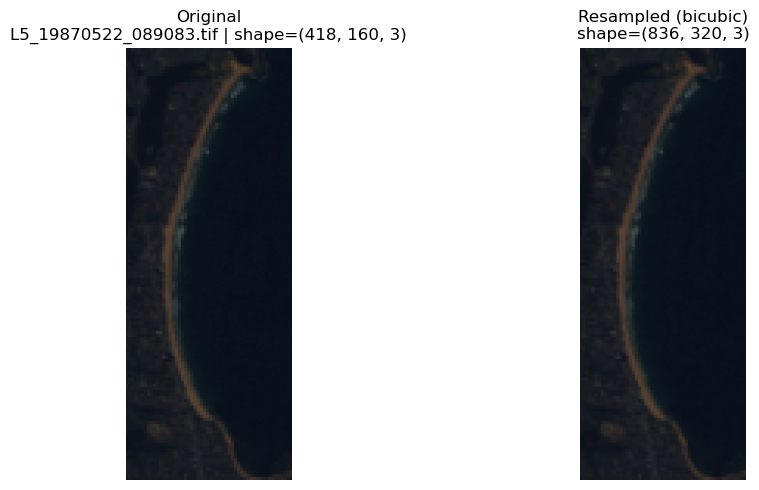

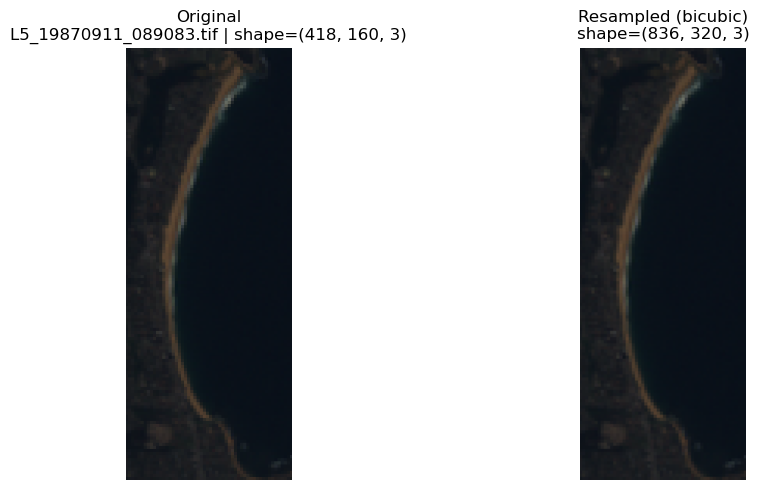

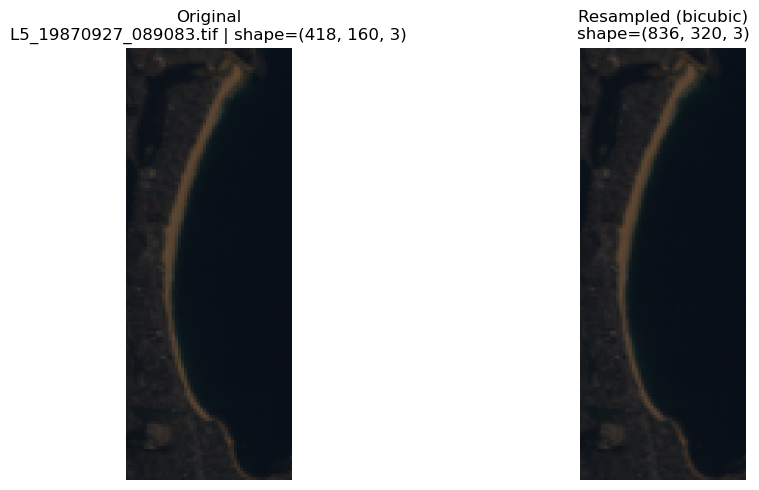

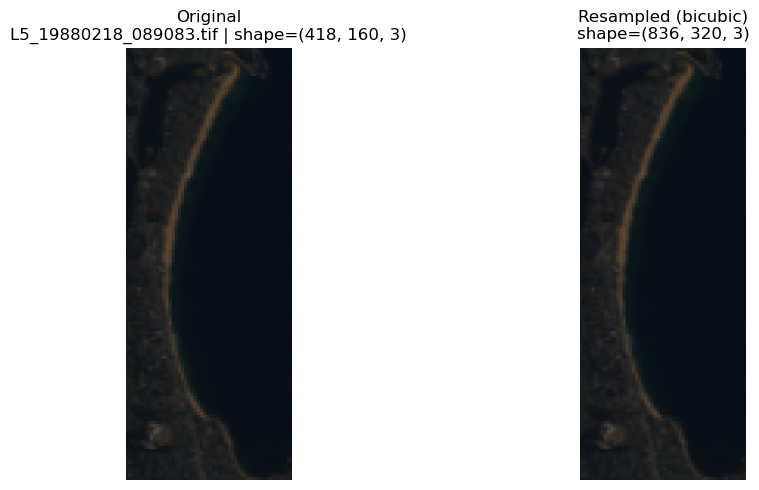

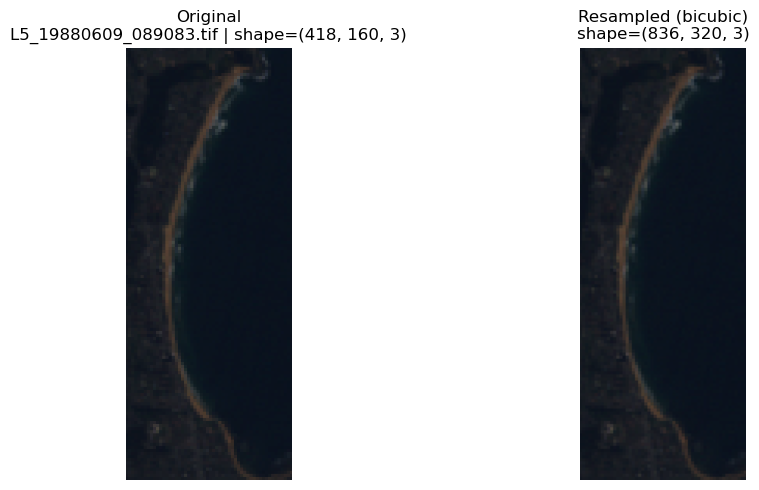

In [6]:
# Plot original vs resampled (no file writing in this test).
# For multi-band rasters, visualize RGB only (bands 0, 1, 2).
technique = 'bicubic'  # change to 'bilinear' to compare
upsample_scale = 2


def to_display_array(arr: np.ndarray) -> np.ndarray:
    if arr.ndim == 2:
        return arr
    if arr.ndim == 3:
        if arr.shape[2] >= 3:
            return arr[:, :, :3]
        return arr[:, :, 0]
    raise ValueError(f'Unexpected array shape for plotting: {arr.shape}')


for fp in tiff_files:
    with rasterio.open(fp) as src:
        original = src.read()  # (bands, h, w)
        height, width = src.height, src.width

    if original.shape[0] == 1:
        original_array = original[0]
    else:
        original_array = np.transpose(original, (1, 2, 0))

    desired_resolution = (height * upsample_scale, width * upsample_scale)
    upsampled_array = resample_tiff(
        tiff_path=fp,
        desired_resolution=desired_resolution,
        technique=technique,
        save_path=None,  # explicitly do not save for this test
    )

    original_display = to_display_array(original_array)
    upsampled_display = to_display_array(upsampled_array)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(original_display, cmap='gray' if original_display.ndim == 2 else None)
    axes[0].set_title(f'Original\n{Path(fp).name} | shape={original_display.shape}')
    axes[0].axis('off')

    axes[1].imshow(upsampled_display, cmap='gray' if upsampled_display.ndim == 2 else None)
    axes[1].set_title(f'Resampled ({technique})\nshape={upsampled_display.shape}')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()